<a href="https://colab.research.google.com/github/KelelAngeAgnimel/Machine-Learning/blob/main/MachineLearningProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 Data

In [19]:
import os
import pandas as pd

os.environ["KAGGLE_TOKEN"] = "KGAT_fc6f7eee960a8b8070983dc77cd0266e"
os.environ["KAGGLE_USERNAME"] = "kelel94"

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write(f'{{"username":"kelel94","key":"{os.environ["KAGGLE_TOKEN"]}\"}}')
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!pip install kaggle -q
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset
!unzip -o -q fake-and-real-news-dataset.zip   # ← -o ajouté ici

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")
print("Fake:", fake.shape, "| True:", true.shape)

Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
fake-and-real-news-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Fake: (23481, 4) | True: (21417, 4)


In [20]:
print("Taille totale du dataset :", len(df))
print("─" * 40)
print("Training set :", X_train.shape[0], "articles (80%)")
print("Test set     :", X_test.shape[0],  "articles (20%)")
print("─" * 40)
print("Dont dans le training set :")
print("  Fake news  :", sum(y_train == 1))
print("  Real news  :", sum(y_train == 0))
print("Dont dans le test set :")
print("  Fake news  :", sum(y_test == 1))
print("  Real news  :", sum(y_test == 0))

Taille totale du dataset : 44898
────────────────────────────────────────
Training set : 31428 articles (80%)
Test set     : 6735 articles (20%)
────────────────────────────────────────
Dont dans le training set :
  Fake news  : 16416
  Real news  : 15012
Dont dans le test set :
  Fake news  : 3547
  Real news  : 3188


Step 2

In [21]:
# ── STEP 2: Fusion + Preprocessing ─────────────────────
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


fake["label"] = 1   # 1 = fake news
true["label"] = 0   # 0 = vraie information

df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset total :", df.shape)
print(df["label"].value_counts())

# Text cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["content"] = (df["title"] + " " + df["text"]).apply(clean_text)

# Separation of train and test activities (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df["content"], df["label"], test_size=0.2, random_state=42
)

# Vectorisation
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("Taille train :", X_train_vec.shape)
print("Taille test  :", X_test_vec.shape)
print("Prétraitement terminé !")

Dataset total : (44898, 5)
label
1    23481
0    21417
Name: count, dtype: int64
Taille train : (35918, 5000)
Taille test  : (8980, 5000)
Prétraitement terminé !


Step 3

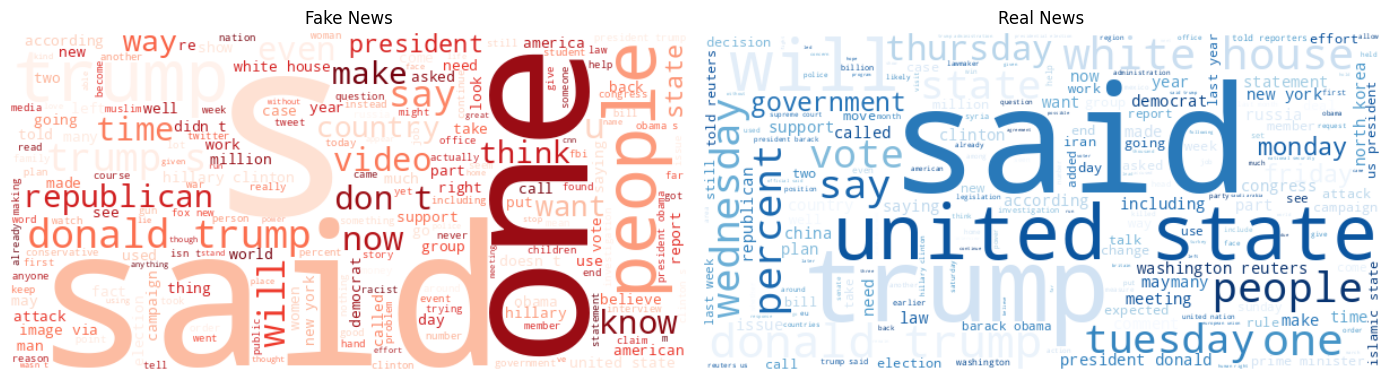

In [22]:
# ── ÉTAPE 3 : Word Cloud ──────────────────────────────────────
from wordcloud import WordCloud
import matplotlib.pyplot as plt


fake_text = " ".join(df[df.label == 1]["content"])
true_text = " ".join(df[df.label == 0]["content"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, text, title, cmap in zip(axes,
    [fake_text, true_text],
    ["Fake News", "Real News"],
    ["Reds", "Blues"]):
    wc = WordCloud(width=600, height=300, background_color='white', colormap=cmap).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)

plt.tight_layout()
plt.show()

Step 4

KNN training in progress...
  k=3 → Accuracy : 0.757
  k=5 → Accuracy : 0.723
  k=10 → Accuracy : 0.682
  k=15 → Accuracy : 0.651
  k=30 → Accuracy : 0.898

 Best k : 30 with an accuracy of 0.898


/tmp/ipykernel_659/657655692.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(list(scores_knn.keys()), list(scores_knn.values()), 'bo-', color='purple')


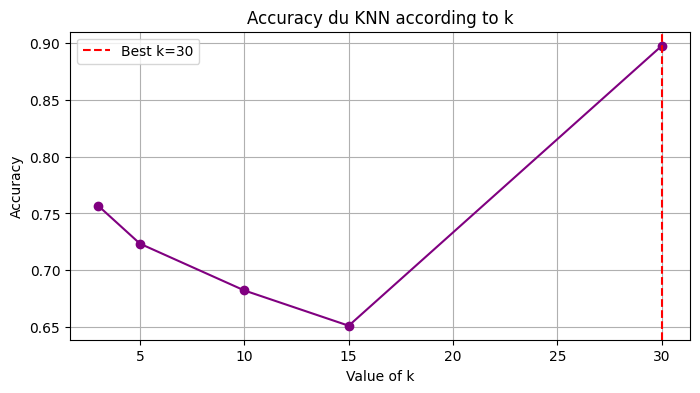

In [23]:
# ── ÉTAPE 4A : KNN — comparaison de différentes valeurs de k ──
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

print("KNN training in progress...")

scores_knn = {}
for k in [3, 5, 10, 15, 30]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_vec, y_train)
    y_pred = knn.predict(X_test_vec)
    scores_knn[k] = accuracy_score(y_test, y_pred)
    print(f"  k={k} → Accuracy : {scores_knn[k]:.3f}")

best_k = max(scores_knn, key=scores_knn.get)
print(f"\n Best k : {best_k} with an accuracy of {scores_knn[best_k]:.3f}")

# Accuracy curve vs k
plt.figure(figsize=(8, 4))
plt.plot(list(scores_knn.keys()), list(scores_knn.values()), 'bo-', color='purple')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.title("Accuracy du KNN according to k")
plt.legend()
plt.grid()
plt.show()

In [24]:
# ── STEP 4B: Logistic Regression ─────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print("Logistic Regression Training in progress...")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_vec, y_train)
y_pred_lr = lr.predict(X_test_vec)

print(f" Accuracy Logistic Regression {accuracy_score(y_test, y_pred_lr):.3f}")
print("\n Detailed report :")
print(classification_report(y_test, y_pred_lr, target_names=["Real News", "Fake News"]))

Logistic Regression Training in progress...
 Accuracy Logistic Regression 0.989

 Detailed report :
              precision    recall  f1-score   support

   Real News       0.99      0.99      0.99      4270
   Fake News       0.99      0.99      0.99      4710

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



K-Means training in progress...


/tmp/ipykernel_659/72245285.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(k_values, inertia_values, 'bo-', color='purple')


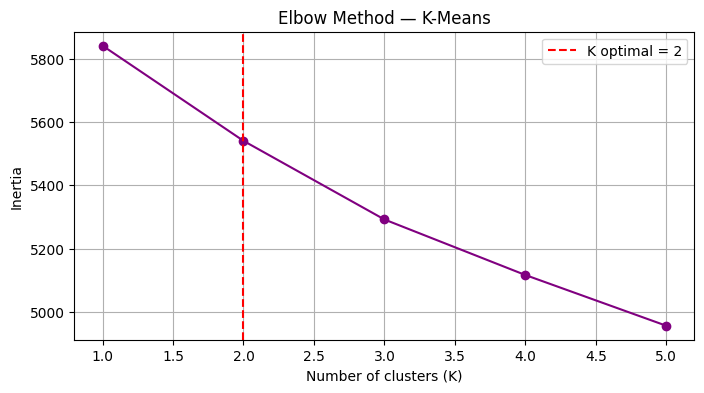

Final inertia K-Means (k=2) : 5540.73


In [25]:
# ── ÉTAPE 4C : K-Means (clustering non supervisé) ────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
import numpy as np

print("K-Means training in progress...")

# Dimension reduction
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_train_vec)

km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(X_reduced)

# Visualizing inertia
inertia_values = []
k_values = range(1, 6)
for k in k_values:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_test.fit(X_reduced)
    inertia_values.append(km_test.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia_values, 'bo-', color='purple')
plt.axvline(x=2, color='red', linestyle='--', label='K optimal = 2')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — K-Means")
plt.legend()
plt.grid()
plt.show()

print(f"Final inertia K-Means (k=2) : {inertia_values[1]:.2f}")

Step 5

/tmp/ipykernel_659/3967779967.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(list(scores_knn.keys()), list(scores_knn.values()), 'bo-', color='purple')


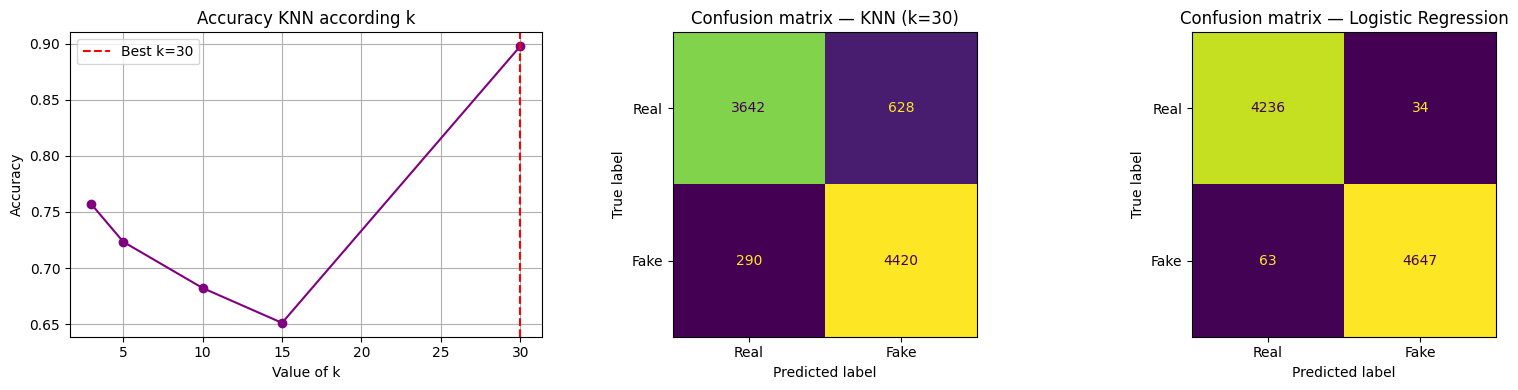


Modèle                      Accuracy  Précision     Rappel         F1
KNN (k=30)                    0.898     0.876     0.938     0.906
Logistic Regression           0.989     0.993     0.987     0.990


In [26]:
# ── STEP 5: Complete evaluation of the models ─────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
from sklearn.neighbors import KNeighborsClassifier

# ── Figure 1: KNN Accuracy according to k────────────────────────
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(list(scores_knn.keys()), list(scores_knn.values()), 'bo-', color='purple')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.title("Accuracy KNN according k")
plt.legend()
plt.grid()

# ── Figure 2: KNN Confusion Matrix ────────────────────
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_vec, y_train)
y_pred_knn = knn_best.predict(X_test_vec)

plt.subplot(1, 3, 2)
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Real", "Fake"]).plot(ax=plt.gca(), colorbar=False)
plt.title(f"Confusion matrix — KNN (k={best_k})")

# ── Figure 3: Confusion Matrix Logistic Regression ──
plt.subplot(1, 3, 3)
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["Real", "Fake"]).plot(ax=plt.gca(), colorbar=False)
plt.title("Confusion matrix — Logistic Regression")

plt.tight_layout()
plt.show()

# ── Final comparison table───────────────────────────────────

print("\n" + "="*65)
print(f"{'Modèle':<25} {'Accuracy':>10} {'Précision':>10} {'Rappel':>10} {'F1':>10}")
print("="*65)

models = {
    f"KNN (k={best_k})":         y_pred_knn,
    "Logistic Regression":       y_pred_lr,
}

for name, y_pred in models.items():
    print(f"{name:<25}"
          f"{accuracy_score(y_test, y_pred):>10.3f}"
          f"{precision_score(y_test, y_pred):>10.3f}"
          f"{recall_score(y_test, y_pred):>10.3f}"
          f"{f1_score(y_test, y_pred):>10.3f}")

print("="*65)

Step 6

Modèle                      Accuracy  Précision     Rappel         F1
KNN (k=30)                     0.898      0.876      0.938      0.906
Logistic Regression            0.989      0.993      0.987      0.990


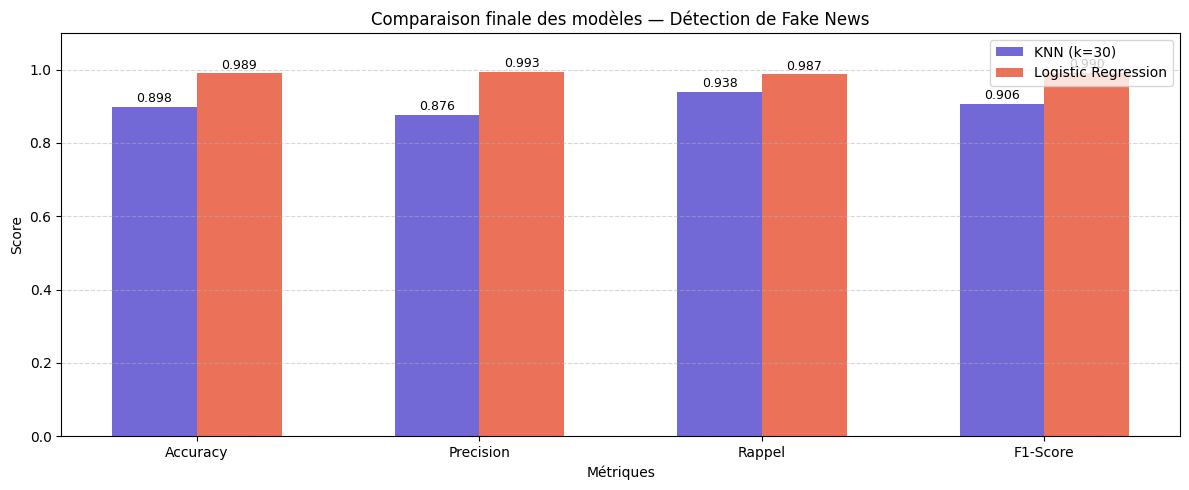


 CONCLUSION
-----------------------------------------------------------------
  Best Model : Logistic Regression
   → F1-Score     : 0.990
   → Accuracy     : 0.989
   → Précision    : 0.993
   → Rappel       : 0.987
-----------------------------------------------------------------

Analyse :
- Logistic regression is generally faster and more accurate than KNN on TF-IDF text data.

- KNN suffers from the 'dimension problem': with 5000 features, distances become less discriminating.

- A high F1 score confirms that the model effectively detects fake news while avoiding false positives.



In [27]:
# ──STEP 6: Final Comparison and Conclusion ────────────────
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# ── Comparison table ────────────────────────────────────────
models = {
    f"KNN (k={best_k})":      knn_best.predict(X_test_vec),
    "Logistic Regression":    y_pred_lr,
}

print("=" * 65)
print(f"{'Modèle':<25} {'Accuracy':>10} {'Précision':>10} {'Rappel':>10} {'F1':>10}")
print("=" * 65)

resultats = {}
for name, y_pred in models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    resultats[name] = [acc, prec, rec, f1]
    print(f"{name:<25} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f}")

print("=" * 65)

# ── Comparative graph of the 4 metrics─────────────────────
noms     = list(resultats.keys())
metriques = ["Accuracy", "Precision", "Rappel", "F1-Score"]
couleurs  = ["#5B4FCF", "#E8593C"]

x     = np.arange(len(metriques))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nom, vals) in enumerate(resultats.items()):
    bars = ax.bar(x + i * width, vals, width, label=nom, color=couleurs[i], alpha=0.85)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Métriques")
ax.set_ylabel("Score")
ax.set_title("Comparaison finale des modèles — Détection de Fake News")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metriques)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


print("\n CONCLUSION")
print("-" * 65)

meilleur = max(resultats, key=lambda x: resultats[x][3])  # meilleur F1
print(f"  Best Model : {meilleur}")
print(f"   → F1-Score     : {resultats[meilleur][3]:.3f}")
print(f"   → Accuracy     : {resultats[meilleur][0]:.3f}")
print(f"   → Précision    : {resultats[meilleur][1]:.3f}")
print(f"   → Rappel       : {resultats[meilleur][2]:.3f}")
print("-" * 65)
print("""
Analyse :
- Logistic regression is generally faster and more accurate than KNN on TF-IDF text data.

- KNN suffers from the 'dimension problem': with 5000 features, distances become less discriminating.

- A high F1 score confirms that the model effectively detects fake news while avoiding false positives.
""")

Step 8

Détection Overfitting / Underfitting
Modèle                       Train Acc      Val Acc       Statut
KNN (k=30)                       0.906        0.765      Overfit
Logistic Regression              0.995        0.917     Good fit


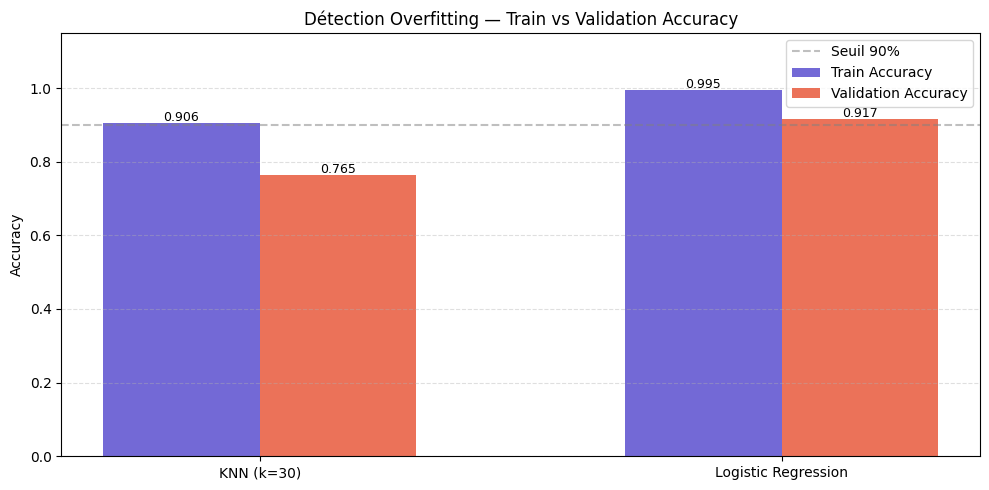

In [28]:
# KNN + Cross-Validation

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

print("Détection Overfitting / Underfitting")
print("=" * 55)
print(f"{'Modèle':<25} {'Train Acc':>12} {'Val Acc':>12} {'Statut':>12}")
print("=" * 55)

modeles = {
    f"KNN (k={best_k})": KNeighborsClassifier(n_neighbors=best_k),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
}

resultats_fit = {}
for nom, modele in modeles.items():
    modele.fit(X_train_vec, y_train)
    train_acc = accuracy_score(y_train, modele.predict(X_train_vec))
    val_acc   = accuracy_score(y_val,   modele.predict(X_val_vec))
    diff      = train_acc - val_acc

    if diff > 0.10:
        statut = " Overfit"
    elif train_acc < 0.75 and val_acc < 0.75:
        statut = " Underfit"
    else:
        statut = " Good fit"

    resultats_fit[nom] = (train_acc, val_acc)
    print(f"{nom:<25} {train_acc:>12.3f} {val_acc:>12.3f} {statut:>12}")

print("=" * 55)

# Graphique Train vs Validation
noms       = list(resultats_fit.keys())
train_accs = [v[0] for v in resultats_fit.values()]
val_accs   = [v[1] for v in resultats_fit.values()]

x     = range(len(noms))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], train_accs, width, label="Train Accuracy",      color="#5B4FCF", alpha=0.85)
ax.bar([i + width/2 for i in x], val_accs,   width, label="Validation Accuracy", color="#E8593C", alpha=0.85)

for i, (tr, va) in enumerate(zip(train_accs, val_accs)):
    ax.text(i - width/2, tr + 0.005, f"{tr:.3f}", ha='center', fontsize=9)
    ax.text(i + width/2, va + 0.005, f"{va:.3f}", ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(noms)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Accuracy")
ax.set_title("Détection Overfitting — Train vs Validation Accuracy")
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label="Seuil 90%")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Step 8

   KNN — CROSS-VALIDATION OPTIMIZATION
  k= 3  |  Fold scores: [0.736 0.74  0.734 0.737 0.738]  |  Mean: 0.737  Std: 0.002
  k= 5  |  Fold scores: [0.699 0.709 0.702 0.705 0.703]  |  Mean: 0.704  Std: 0.003
  k=10  |  Fold scores: [0.659 0.905 0.667 0.672 0.666]  |  Mean: 0.714  Std: 0.096
  k=15  |  Fold scores: [0.864 0.905 0.633 0.824 0.64 ]  |  Mean: 0.773  Std: 0.115
  k=30  |  Fold scores: [0.902 0.901 0.891 0.891 0.893]  |  Mean: 0.895  Std: 0.005

 Best k (CV): 30  →  Mean Accuracy: 0.895

Test Accuracy (best KNN): 0.898

Detailed Report:
              precision    recall  f1-score   support

   Real News       0.93      0.85      0.89      4270
   Fake News       0.88      0.94      0.91      4710

    accuracy                           0.90      8980
   macro avg       0.90      0.90      0.90      8980
weighted avg       0.90      0.90      0.90      8980



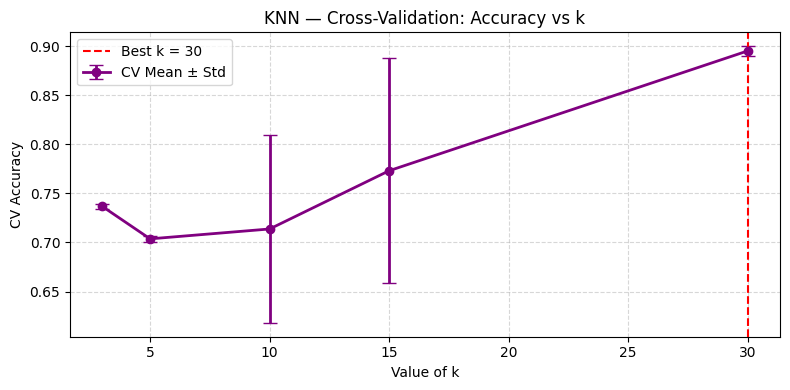

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("   KNN — CROSS-VALIDATION OPTIMIZATION")
print("=" * 60)

# ── 5-fold stratified cross-validation ───────────────────────
# StratifiedKFold ensures each fold keeps the same
# Fake/Real class ratio as the full dataset.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values = [3, 5, 10, 15, 30]
cv_means, cv_stds = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_vec, y_train,
                             cv=skf, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"  k={k:>2}  |  Fold scores: {np.round(scores, 3)}  "
          f"|  Mean: {scores.mean():.3f}  Std: {scores.std():.3f}")

# ── Best k based on cross-validation ─────────────────────────
best_k_cv = k_values[np.argmax(cv_means)]
print(f"\n Best k (CV): {best_k_cv}  →  Mean Accuracy: {max(cv_means):.3f}")
print("=" * 60)

# ── Retrain the best KNN on full training set ─────────────────
knn_best = KNeighborsClassifier(n_neighbors=best_k_cv)
knn_best.fit(X_train_vec, y_train)
y_pred_knn = knn_best.predict(X_test_vec)

print(f"\nTest Accuracy (best KNN): {accuracy_score(y_test, y_pred_knn):.3f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_knn,
                             target_names=["Real News", "Fake News"]))

# ── Plot: CV mean accuracy vs k with error bars ───────────────
plt.figure(figsize=(8, 4))
plt.errorbar(k_values, cv_means, yerr=cv_stds,
             fmt='o-', color='purple', capsize=5,
             linewidth=2, label='CV Mean ± Std')
plt.axvline(x=best_k_cv, color='red', linestyle='--',
            label=f'Best k = {best_k_cv}')
plt.xlabel("Value of k")
plt.ylabel("CV Accuracy")
plt.title("KNN — Cross-Validation: Accuracy vs k")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

   LOGISTIC REGRESSION — GRADIENT DESCENT OPTIMIZATION

How it works:
  Standard LR minimises log-loss in one go (LBFGS solver).
  SGDClassifier minimises the SAME log-loss but using
  Stochastic Gradient Descent: it updates model weights
  after each mini-batch, epoch by epoch.
  → Faster on large text datasets (TF-IDF sparse matrices).
  → Lets us watch the learning curve in real time.

Final Training Accuracy  : 0.988
Final Validation Accuracy: 0.984

Detailed Report (SGD model):
              precision    recall  f1-score   support

   Real News       0.98      0.99      0.98      4270
   Fake News       0.99      0.98      0.98      4710

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



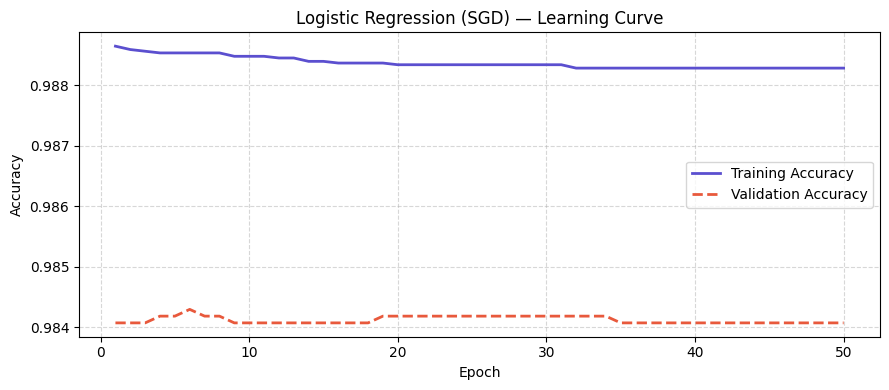

In [30]:
# Logistic Regression + Gradient Descent

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("   LOGISTIC REGRESSION — GRADIENT DESCENT OPTIMIZATION")
print("=" * 60)
print("""
How it works:
  Standard LR minimises log-loss in one go (LBFGS solver).
  SGDClassifier minimises the SAME log-loss but using
  Stochastic Gradient Descent: it updates model weights
  after each mini-batch, epoch by epoch.
  → Faster on large text datasets (TF-IDF sparse matrices).
  → Lets us watch the learning curve in real time.
""")

# ── SGD model setup ───────────────────────────────────────────
# loss='log_loss'     → logistic regression objective
# learning_rate='optimal' → sklearn auto-tunes the step size
# penalty='l2'        → L2 regularisation (avoids overfitting)
sgd = SGDClassifier(
    loss='log_loss',
    learning_rate='optimal',
    penalty='l2',
    max_iter=1,          # we manually loop over epochs
    warm_start=True,     # keep weights between partial_fit calls
    random_state=42,
    tol=None
)

# ── Epoch-by-epoch training ───────────────────────────────────
epochs = 50
train_accs, test_accs = [], []
classes = np.unique(y_train)

for epoch in range(1, epochs + 1):
    sgd.partial_fit(X_train_vec, y_train, classes=classes)
    train_accs.append(accuracy_score(y_train, sgd.predict(X_train_vec)))
    test_accs.append(accuracy_score(y_test,  sgd.predict(X_test_vec)))

print(f"Final Training Accuracy  : {train_accs[-1]:.3f}")
print(f"Final Validation Accuracy: {test_accs[-1]:.3f}")
print("=" * 60)

# ── Detailed report on the final model ───────────────────────
print("\nDetailed Report (SGD model):")
print(classification_report(y_test, sgd.predict(X_test_vec),
                             target_names=["Real News", "Fake News"]))

# ── Learning curve ────────────────────────────────────────────
# If training accuracy >> validation accuracy → overfitting
# If both stay low                           → underfitting
plt.figure(figsize=(9, 4))
plt.plot(range(1, epochs + 1), train_accs,
         label="Training Accuracy", color="#5B4FCF", linewidth=2)
plt.plot(range(1, epochs + 1), test_accs,
         label="Validation Accuracy", color="#E8593C",
         linewidth=2, linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Logistic Regression (SGD) — Learning Curve")
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

   K-MEANS — ELBOW + SILHOUETTE OPTIMIZATION

How it works:
  K-Means already uses an internal optimisation loop
  (minimising inertia via coordinate descent).
  Here we go further: we find the best K by combining:
    • Elbow Method     → look for the 'elbow' in inertia
    • Silhouette Score → measures how well each point
                         fits its cluster vs the nearest one
                         (1 = perfect, 0 = overlap, -1 = wrong)

Reduced shape: (35918, 50)  (was (35918, 5000))
  K=2  |  Inertia: 5,541  |  Silhouette: 0.053
  K=3  |  Inertia: 5,292  |  Silhouette: 0.068
  K=4  |  Inertia: 5,117  |  Silhouette: 0.056
  K=5  |  Inertia: 4,956  |  Silhouette: 0.057
  K=6  |  Inertia: 4,831  |  Silhouette: 0.057
  K=7  |  Inertia: 4,696  |  Silhouette: 0.046
  K=8  |  Inertia: 4,576  |  Silhouette: 0.048

 Best K (Silhouette): 3  →  Score: 0.068


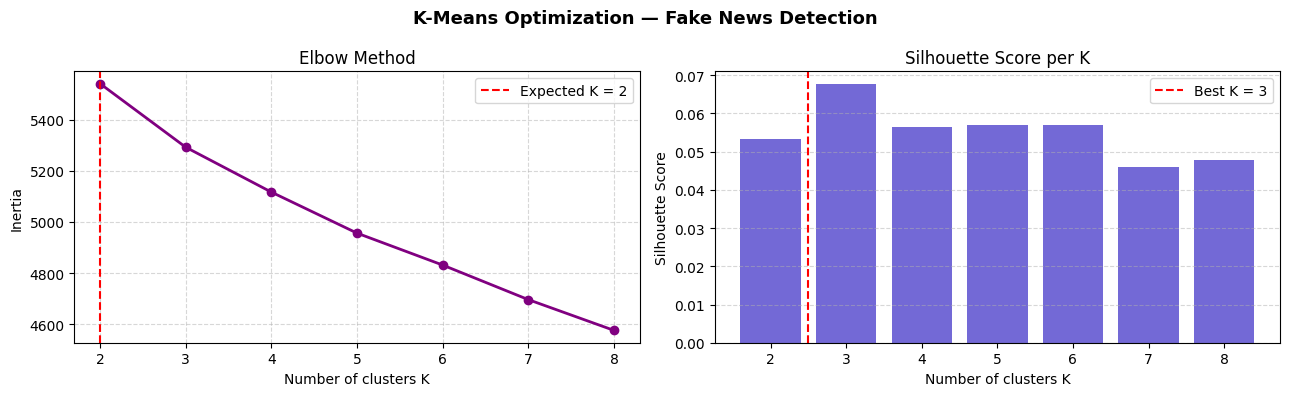


Final K-Means (K=3)  →  Inertia: 5,292


In [31]:
# K-Means + Elbow Method + Silhouette

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("   K-MEANS — ELBOW + SILHOUETTE OPTIMIZATION")
print("=" * 60)
print("""
How it works:
  K-Means already uses an internal optimisation loop
  (minimising inertia via coordinate descent).
  Here we go further: we find the best K by combining:
    • Elbow Method     → look for the 'elbow' in inertia
    • Silhouette Score → measures how well each point
                         fits its cluster vs the nearest one
                         (1 = perfect, 0 = overlap, -1 = wrong)
""")

# ── Dimensionality reduction (TF-IDF → 50 components) ────────
# K-Means struggles in high dimensions (curse of dimensionality).
# TruncatedSVD reduces the TF-IDF matrix to 50 dense dimensions.
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_train_vec)
print(f"Reduced shape: {X_reduced.shape}  (was {X_train_vec.shape})")

# ── Elbow + Silhouette for K = 2 to 8 ────────────────────────
k_range      = range(2, 9)
inertias     = []
silhouettes  = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_reduced, labels,
                                        sample_size=2000,
                                        random_state=42))
    print(f"  K={k}  |  Inertia: {km.inertia_:,.0f}  "
          f"|  Silhouette: {silhouettes[-1]:.3f}")

best_k_sil = list(k_range)[np.argmax(silhouettes)]
print(f"\n Best K (Silhouette): {best_k_sil}  "
      f"→  Score: {max(silhouettes):.3f}")
print("=" * 60)

# ── Side-by-side plots: Elbow + Silhouette ────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
ax1.plot(list(k_range), inertias, 'o-', color='purple', linewidth=2)
ax1.axvline(x=2, color='red', linestyle='--', label='Expected K = 2')
ax1.set_xlabel("Number of clusters K")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.legend()
ax1.grid(linestyle='--', alpha=0.5)

# Silhouette
ax2.bar(list(k_range), silhouettes, color='#5B4FCF', alpha=0.85)
ax2.axvline(x=best_k_sil - 0.5, color='red', linestyle='--',
            label=f'Best K = {best_k_sil}')
ax2.set_xlabel("Number of clusters K")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score per K")
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("K-Means Optimization — Fake News Detection",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Final model with optimal K ────────────────────────────────
km_best = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
km_best.fit(X_reduced)
print(f"\nFinal K-Means (K={best_k_sil})  →  Inertia: {km_best.inertia_:,.0f}")